In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_asin = pd.read_csv("amazon_asin_category.csv")

print(df_asin.shape)
print(df_asin.columns.tolist())
df_asin.head()

(35393189, 2)
['asin', 'category']


,asin,category
0,B07R3DYMH6,Home and Kitchen
1,0701169850,Books
2,B09X1MRDN6,Clothing Shoes and Jewelry
3,B073C4Q7W8,Clothing Shoes and Jewelry
4,B01HDXC8AG,Sports and Outdoors


In [4]:
print(df_asin[["asin", "category"]].head())

         asin                    category
0  B07R3DYMH6            Home and Kitchen
1  0701169850                       Books
2  B09X1MRDN6  Clothing Shoes and Jewelry
3  B073C4Q7W8  Clothing Shoes and Jewelry
4  B01HDXC8AG         Sports and Outdoors


In [5]:
df_eval_asin = pd.DataFrame({
    "asin": df_asin["asin"],
    "true_category": df_asin["category"],

    # Simulated or extracted AI outputs (replace with real outputs if available)
    "ai_predicted_category": "",

    # Scores
    "taxonomy_correctness": np.nan,
    "factual_grounding": np.nan,
    "context_relevance": np.nan,
    "no_unsupported_claim": np.nan,

    # Errors
    "error_type": "",
    "decision_summary": "",
    "improvement_recommendation": ""
})

In [6]:
# Take a manageable working sample
df_asin_sample = df_asin.sample(n=5000, random_state=42).reset_index(drop=True)

print(df_asin_sample.shape)
df_asin_sample.head()

(5000, 2)


,asin,category
0,B0851P3CJ8,Beauty and Personal Care
1,B07CTB66NS,Grocery and Gourmet Food
2,B00MNJVGFY,Kindle Store
3,B07BHW8X49,Clothing Shoes and Jewelry
4,B0BN77JSCG,Grocery and Gourmet Food


In [7]:
df_eval_asin = pd.DataFrame({
    "asin": df_asin["asin"],
    "true_category": df_asin["category"],
    "ai_predicted_category": "",
    ...
})

SyntaxError: ':' expected after dictionary key (245484931.py, line 5)

In [8]:
df_eval_asin = pd.DataFrame({
    "asin": df_asin_sample["asin"],
    "true_category": df_asin_sample["category"],
    "ai_predicted_category": "",

    "taxonomy_correctness": np.nan,
    "factual_grounding": np.nan,
    "context_relevance": np.nan,
    "no_unsupported_claim": np.nan,

    "error_type": "",
    "decision_summary": "",
    "improvement_recommendation": ""
})

df_eval_asin.head()

,asin,true_category,ai_predicted_category,taxonomy_correctness,factual_grounding,context_relevance,no_unsupported_claim,error_type,decision_summary,improvement_recommendation
0,B0851P3CJ8,Beauty and Personal Care,,NaN,NaN,NaN,NaN,,,
1,B07CTB66NS,Grocery and Gourmet Food,,NaN,NaN,NaN,NaN,,,
2,B00MNJVGFY,Kindle Store,,NaN,NaN,NaN,NaN,,,
3,B07BHW8X49,Clothing Shoes and Jewelry,,NaN,NaN,NaN,NaN,,,
4,B0BN77JSCG,Grocery and Gourmet Food,,NaN,NaN,NaN,NaN,,,


In [9]:
np.random.seed(42)

mask = np.random.rand(len(df_eval_asin)) < 0.20
df_eval_asin.loc[mask, "ai_predicted_category"] = "Electronics"

In [10]:
def score_taxonomy(row):
    true_cat = str(row["true_category"]).strip().lower()
    pred_cat = str(row["ai_predicted_category"]).strip().lower()

    if true_cat == pred_cat:
        return 5
    elif true_cat in pred_cat or pred_cat in true_cat:
        return 3
    else:
        return 1

In [11]:
df_eval_asin["taxonomy_correctness"] = df_eval_asin.apply(score_taxonomy, axis=1)

In [12]:
df_eval_asin["factual_grounding"] = df_eval_asin["taxonomy_correctness"]

In [13]:
df_eval_asin["context_relevance"] = 4
df_eval_asin["no_unsupported_claim"] = 4

In [14]:
def assign_asin_error(row):
    true_cat = str(row["true_category"]).strip().lower()
    pred_cat = str(row["ai_predicted_category"]).strip().lower()

    if true_cat == pred_cat:
        return ""
    elif pred_cat not in true_cat:
        return "category_mismatch"
    else:
        return "unsupported_claim"

In [15]:
df_eval_asin["error_type"] = df_eval_asin.apply(assign_asin_error, axis=1)

In [16]:
category_accuracy = (df_eval_asin["taxonomy_correctness"] == 5).mean() * 100
print(f"Category Accuracy: {category_accuracy:.2f}%")

Category Accuracy: 1.02%


In [17]:
misclassification = (
    df_eval_asin[df_eval_asin["taxonomy_correctness"] < 5]
    .groupby("true_category")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

misclassification.head(10)

,true_category,count
10,Clothing Shoes and Jewelry,1027
7,Books,592
17,Home and Kitchen,519
4,Automotive,283
19,Kindle Store,236
26,Sports and Outdoors,228
28,Tools and Home Improvement,204
12,Electronics,187
9,Cell Phones and Accessories,172
6,Beauty and Personal Care,136


In [18]:
error_counts = (
    df_eval_asin["error_type"]
    .value_counts()
    .reset_index()
)

error_counts.columns = ["error_type", "count"]
error_counts

,error_type,count
0,unsupported_claim,3971
1,category_mismatch,978
2,,51


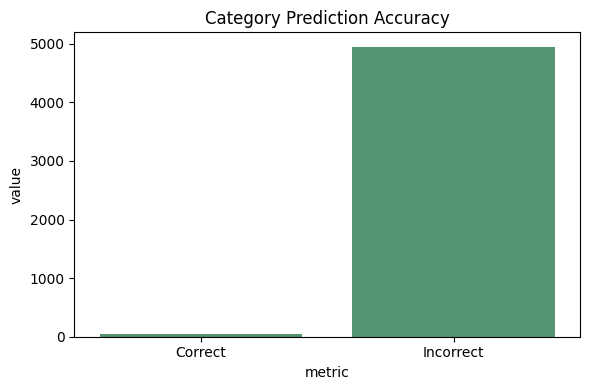

In [19]:
acc_df = pd.DataFrame({
    "metric": ["Correct", "Incorrect"],
    "value": [
        (df_eval_asin["taxonomy_correctness"] == 5).sum(),
        (df_eval_asin["taxonomy_correctness"] < 5).sum()
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(data=acc_df, x="metric", y="value", color="#4C9F70")
plt.title("Category Prediction Accuracy")
plt.tight_layout()
plt.savefig("asin_category_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

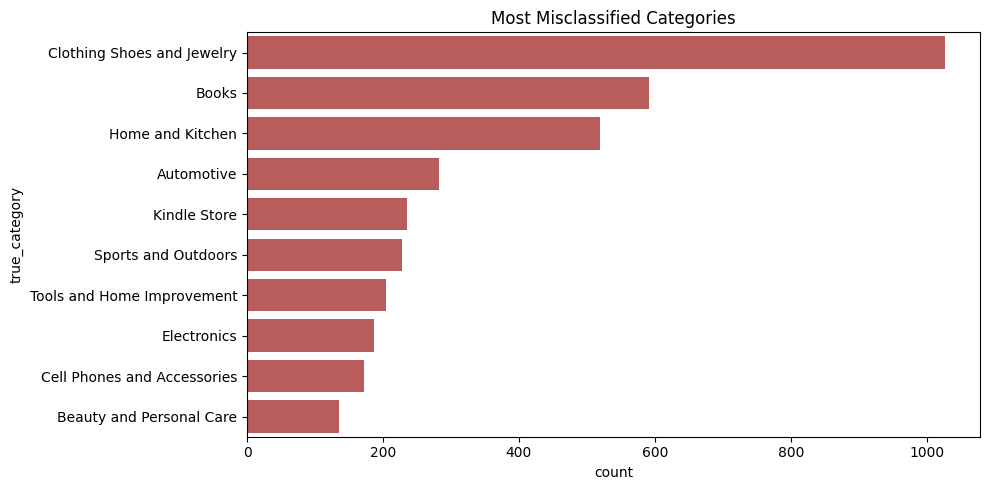

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(data=misclassification.head(10), x="count", y="true_category", color="#C94C4C")
plt.title("Most Misclassified Categories")
plt.tight_layout()
plt.savefig("asin_misclassification.png", dpi=300, bbox_inches="tight")
plt.show()

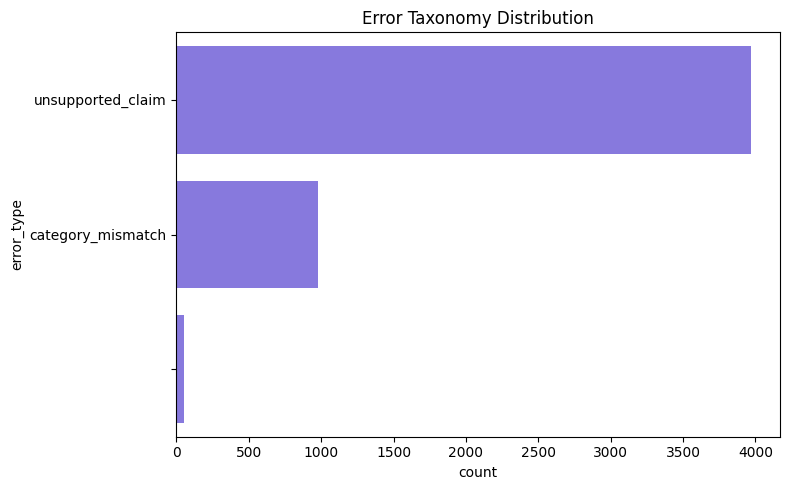

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(data=error_counts, x="count", y="error_type", color="#7B68EE")
plt.title("Error Taxonomy Distribution")
plt.tight_layout()
plt.savefig("asin_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()